# Exploratory Data Analysis (EDA)



## 1. Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")

✓ Imports successful


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [3]:
# Paths
BASE_PATH = os.getcwd()
DATA_PATH = '/content/drive/MyDrive/ArabicMultiFontsDataset'
OUTPUT_PATH = os.path.join(BASE_PATH, 'output')

# Dataset files
BASE_FILENAME = "1_nice_60000_rows"
BINARY_FILE = os.path.join(DATA_PATH, BASE_FILENAME + ".bin")
LABELS_FILE = os.path.join(DATA_PATH, BASE_FILENAME + ".txt")

# Create output directory
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Binary file: {BINARY_FILE}")
print(f"Labels file: {LABELS_FILE}")
print(f"Output path: {OUTPUT_PATH}")

Binary file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.bin
Labels file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.txt
Output path: /content/output


## 3. Load Dataset Metadata

### 3.1 Define Sample Class

In [4]:
class Sample:
    """Represents a single image sample"""
    def __init__(self, gt_text, image_idx, image_height, image_width,
                 image_size, image_start_position):
        self.gtText = gt_text
        self.imageIdx = image_idx
        self.imageHeight = image_height
        self.imageWidth = image_width
        self.imageSize = image_size
        self.imageStartPosition = image_start_position

print("✓ Sample class defined")

✓ Sample class defined


### 3.2 Parse Labels File

In [5]:
def parse_labels_file(labels_file):
    """Parse labels file and extract metadata"""
    samples = []

    print(f"Parsing labels file: {labels_file}")

    with open(labels_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(';')

            if len(parts) < 9:
                continue

            image_idx = parts[0].split(':')[1] if ':' in parts[0] else parts[0]
            start_pos = int(parts[1].split(':')[1]) if ':' in parts[1] else 0
            height = int(parts[2].split(':')[1]) if ':' in parts[2] else 32
            width = int(parts[3].split(':')[1]) if ':' in parts[3] else 128
            size = height * width
            text = parts[8].split(':')[1] if ':' in parts[8] else ''

            samples.append(Sample(text, image_idx, height, width, size, start_pos))

    print(f"✓ Parsed {len(samples)} samples")
    return samples

# Load samples
samples = parse_labels_file(LABELS_FILE)

Parsing labels file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.txt
✓ Parsed 60000 samples


## 4. Dataset Overview

In [6]:
print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nTotal Samples: {len(samples):,}")
print(f"Dataset Name: {BASE_FILENAME}")
print(f"Source: Arabic Handwritten Text Recognition")
print("=" * 70)


DATASET OVERVIEW

Total Samples: 60,000
Dataset Name: 1_nice_60000_rows
Source: Arabic Handwritten Text Recognition


## 5. Basic Statistics

### 5.1 Extract Features

In [7]:
# Extract features from samples
text_lengths = [len(s.gtText) for s in samples]
image_heights = [s.imageHeight for s in samples]
image_widths = [s.imageWidth for s in samples]
image_sizes = [s.imageSize for s in samples]
texts = [s.gtText for s in samples]

# Count unique characters
all_text = ''.join(texts)
unique_chars = set(all_text)
char_freq = Counter(all_text)

print("✓ Features extracted")

✓ Features extracted


### 5.2 Statistical Summary

In [8]:
# Create summary dataframe
summary_data = {
    'Metric': [
        'Total Samples',
        'Unique Characters',
        'Avg Text Length',
        'Min Text Length',
        'Max Text Length',
        'Std Text Length',
        'Avg Image Width',
        'Avg Image Height',
        'Total Characters'
    ],
    'Value': [
        f"{len(samples):,}",
        f"{len(unique_chars)}",
        f"{np.mean(text_lengths):.2f}",
        f"{np.min(text_lengths)}",
        f"{np.max(text_lengths)}",
        f"{np.std(text_lengths):.2f}",
        f"{np.mean(image_widths):.2f}",
        f"{np.mean(image_heights):.2f}",
        f"{len(all_text):,}"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)


STATISTICAL SUMMARY
           Metric   Value
    Total Samples  60,000
Unique Characters      45
  Avg Text Length    7.73
  Min Text Length       7
  Max Text Length      10
  Std Text Length    0.89
  Avg Image Width   72.14
 Avg Image Height   35.00
 Total Characters 463,760


## 6. Data Visualizations

### 6.1 Text Length Distribution

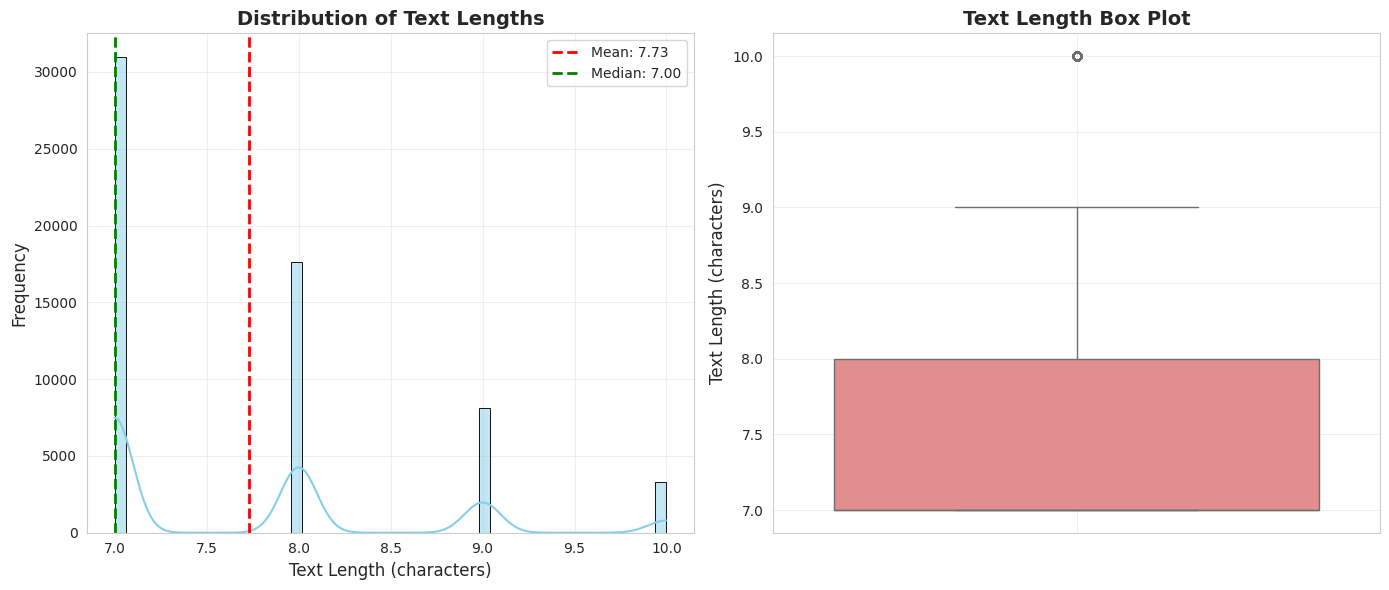

✓ Text length distribution plotted


In [9]:
plt.figure(figsize=(14, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(text_lengths, bins=50, kde=True, color='skyblue', edgecolor='black')
plt.xlabel('Text Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Text Lengths', fontsize=14, fontweight='bold')
plt.axvline(np.mean(text_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(text_lengths):.2f}')
plt.axvline(np.median(text_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(text_lengths):.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
sns.boxplot(y=text_lengths, color='lightcoral')
plt.ylabel('Text Length (characters)', fontsize=12)
plt.title('Text Length Box Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'text_length_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Text length distribution plotted")

### 6.2 Character Frequency Analysis

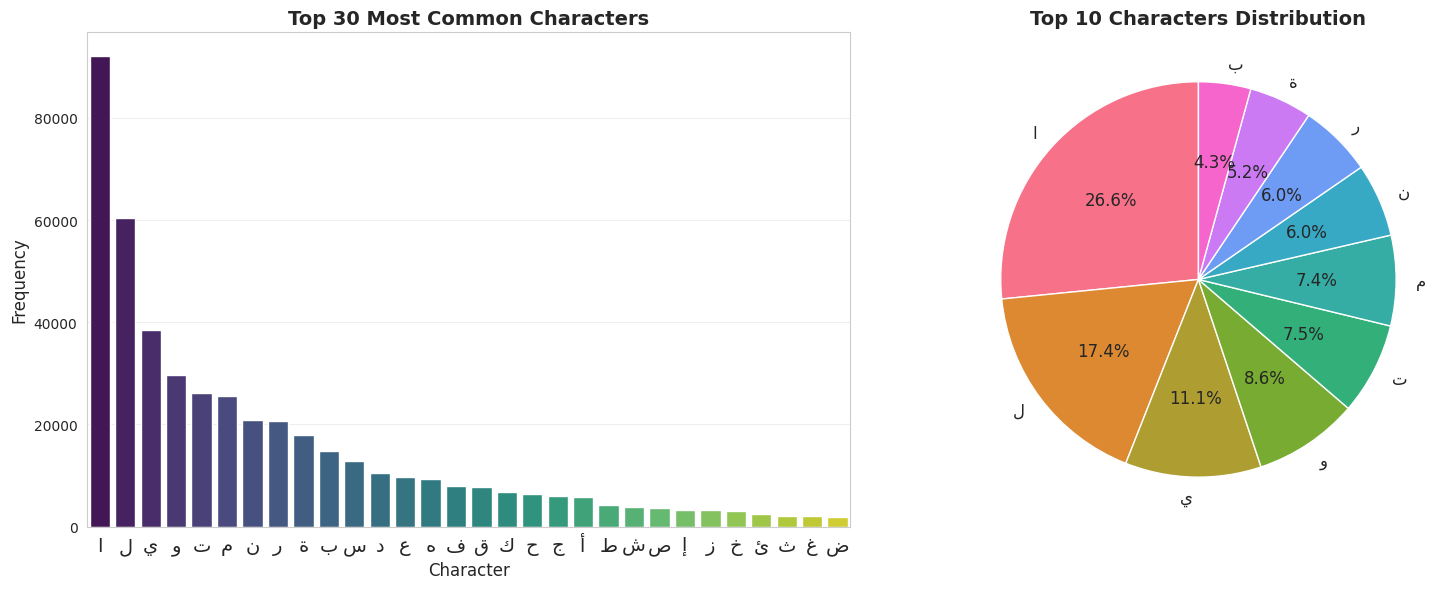

✓ Character frequency plotted


In [10]:
# Top 30 most common characters
top_chars = char_freq.most_common(30)
chars, counts = zip(*top_chars)

plt.figure(figsize=(16, 6))

# Bar plot
plt.subplot(1, 2, 1)
sns.barplot(x=list(chars), y=list(counts), palette='viridis')
plt.xlabel('Character', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 30 Most Common Characters', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Pie chart for top 10
plt.subplot(1, 2, 2)
top_10_chars = char_freq.most_common(10)
labels_10, sizes_10 = zip(*top_10_chars)
colors = sns.color_palette('husl', 10)
plt.pie(sizes_10, labels=labels_10, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
plt.title('Top 10 Characters Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'character_frequency.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Character frequency plotted")

### 6.3 Image Dimensions Analysis

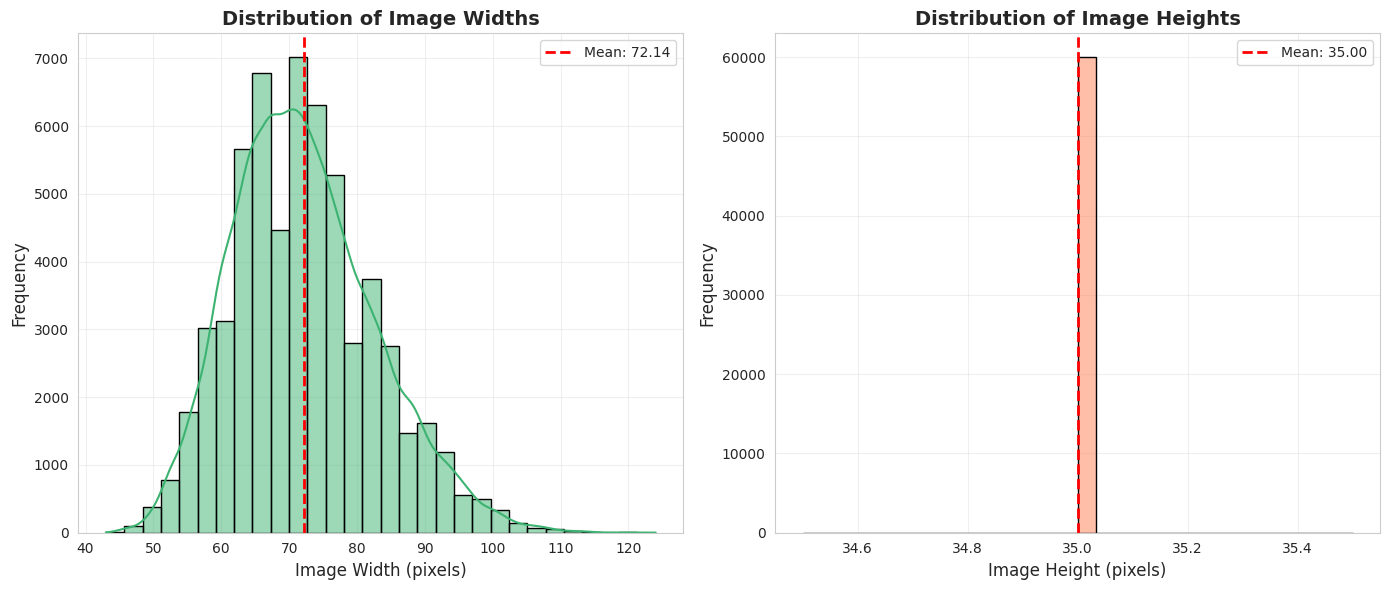

✓ Image dimensions plotted


In [11]:
plt.figure(figsize=(14, 6))

# Width distribution
plt.subplot(1, 2, 1)
sns.histplot(image_widths, bins=30, kde=True, color='mediumseagreen', edgecolor='black')
plt.xlabel('Image Width (pixels)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Image Widths', fontsize=14, fontweight='bold')
plt.axvline(np.mean(image_widths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(image_widths):.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Height distribution
plt.subplot(1, 2, 2)
sns.histplot(image_heights, bins=30, kde=True, color='coral', edgecolor='black')
plt.xlabel('Image Height (pixels)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Image Heights', fontsize=14, fontweight='bold')
plt.axvline(np.mean(image_heights), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(image_heights):.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'image_dimensions.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Image dimensions plotted")

### 6.4 Correlation: Text Length vs Image Width

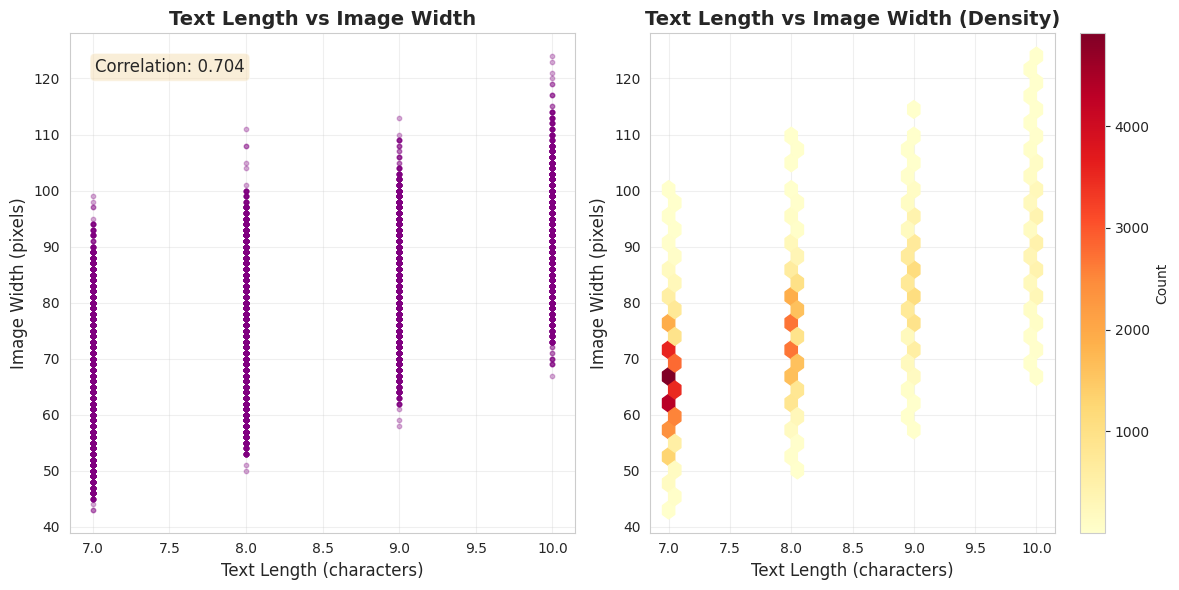

✓ Correlation plotted (r = 0.704)


In [12]:
plt.figure(figsize=(12, 6))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(text_lengths, image_widths, alpha=0.3, s=10, color='purple')
plt.xlabel('Text Length (characters)', fontsize=12)
plt.ylabel('Image Width (pixels)', fontsize=12)
plt.title('Text Length vs Image Width', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add correlation coefficient
correlation = np.corrcoef(text_lengths, image_widths)[0, 1]
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hexbin plot for density
plt.subplot(1, 2, 2)
plt.hexbin(text_lengths, image_widths, gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Count')
plt.xlabel('Text Length (characters)', fontsize=12)
plt.ylabel('Image Width (pixels)', fontsize=12)
plt.title('Text Length vs Image Width (Density)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'text_vs_width_correlation.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Correlation plotted (r = {correlation:.3f})")

## 7. Outlier Detection

### 7.1 Text Length Outliers (IQR Method)


OUTLIER DETECTION - TEXT LENGTH
Q1 (25th percentile): 7.00
Q3 (75th percentile): 8.00
IQR: 1.00
Lower Bound: 5.50
Upper Bound: 9.50

Outliers Found: 3289 (5.48%)


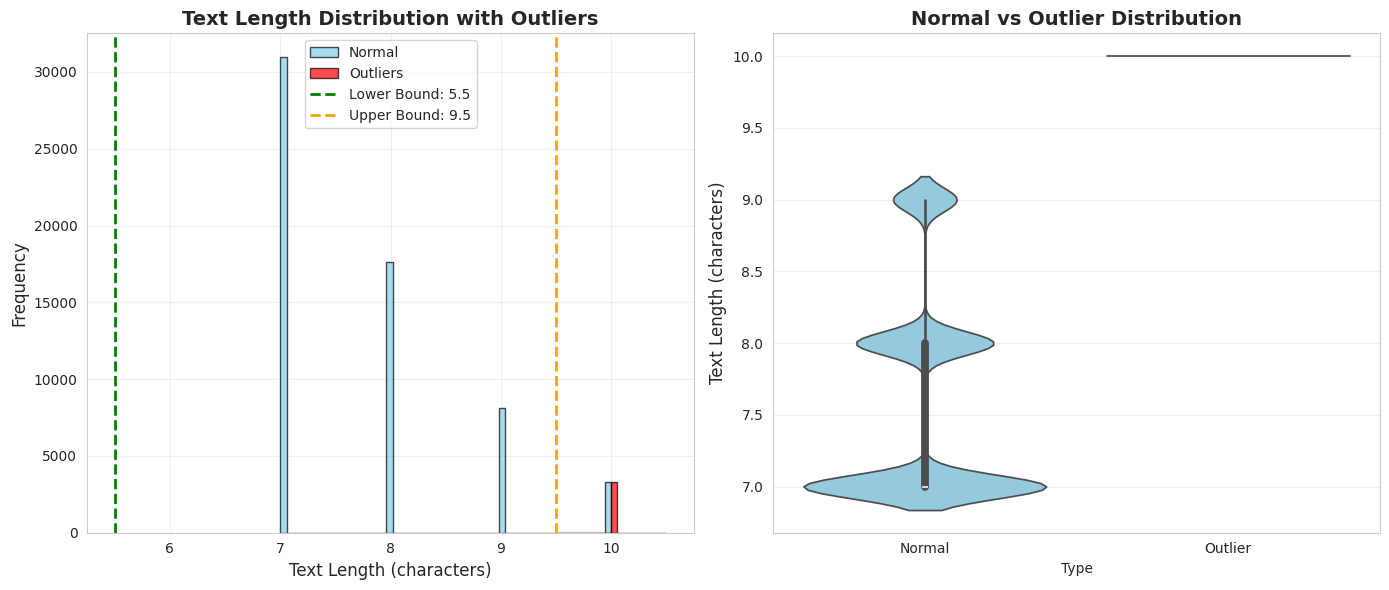

✓ Text length outliers visualized


In [14]:
# Calculate IQR for text lengths
Q1 = np.percentile(text_lengths, 25)
Q3 = np.percentile(text_lengths, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
text_outliers = [s for s in samples if len(s.gtText) < lower_bound or len(s.gtText) > upper_bound]
outlier_lengths = [len(s.gtText) for s in text_outliers]

print("\n" + "=" * 70)
print("OUTLIER DETECTION - TEXT LENGTH")
print("=" * 70)
print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"\nOutliers Found: {len(text_outliers)} ({len(text_outliers)/len(samples)*100:.2f}%)")
print("=" * 70)

# Visualize outliers
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(text_lengths, bins=50, alpha=0.7, color='skyblue', edgecolor='black', label='Normal')
plt.hist(outlier_lengths, bins=20, alpha=0.7, color='red', edgecolor='black', label='Outliers')
plt.axvline(lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound: {lower_bound:.1f}')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Bound: {upper_bound:.1f}')
plt.xlabel('Text Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Text Length Distribution with Outliers', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
data_with_outliers = pd.DataFrame({
    'Type': ['Normal'] * (len(samples) - len(text_outliers)) + ['Outlier'] * len(text_outliers),
    'Length': [len(s.gtText) for s in samples if s not in text_outliers] + outlier_lengths
})
sns.violinplot(data=data_with_outliers, x='Type', y='Length', palette=['skyblue', 'red'])
plt.ylabel('Text Length (characters)', fontsize=12)
plt.title('Normal vs Outlier Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'outliers_text_length.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Text length outliers visualized")

### 7.2 Empty or Very Short Texts

In [15]:
empty_texts = [s for s in samples if len(s.gtText) == 0]
very_short_texts = [s for s in samples if 0 < len(s.gtText) <= 2]

print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)
print(f"Empty Texts: {len(empty_texts)} ({len(empty_texts)/len(samples)*100:.2f}%)")
print(f"Very Short Texts (1-2 chars): {len(very_short_texts)} ({len(very_short_texts)/len(samples)*100:.2f}%)")
print("=" * 70)


DATA QUALITY CHECK
Empty Texts: 0 (0.00%)
Very Short Texts (1-2 chars): 0 (0.00%)


### 7.3 Image Size Outliers

In [16]:
# Calculate IQR for image sizes
Q1_size = np.percentile(image_sizes, 25)
Q3_size = np.percentile(image_sizes, 75)
IQR_size = Q3_size - Q1_size

lower_bound_size = Q1_size - 1.5 * IQR_size
upper_bound_size = Q3_size + 1.5 * IQR_size

size_outliers = [s for s in samples if s.imageSize < lower_bound_size or s.imageSize > upper_bound_size]

print("\n" + "=" * 70)
print("OUTLIER DETECTION - IMAGE SIZE")
print("=" * 70)
print(f"Q1 (25th percentile): {Q1_size:.2f}")
print(f"Q3 (75th percentile): {Q3_size:.2f}")
print(f"IQR: {IQR_size:.2f}")
print(f"Lower Bound: {lower_bound_size:.2f}")
print(f"Upper Bound: {upper_bound_size:.2f}")
print(f"\nOutliers Found: {len(size_outliers)} ({len(size_outliers)/len(samples)*100:.2f}%)")
print("=" * 70)


OUTLIER DETECTION - IMAGE SIZE
Q1 (25th percentile): 2275.00
Q3 (75th percentile): 2765.00
IQR: 490.00
Lower Bound: 1540.00
Upper Bound: 3500.00

Outliers Found: 519 (0.86%)


## 8. Sample Images Visualization


Extracting sample images...


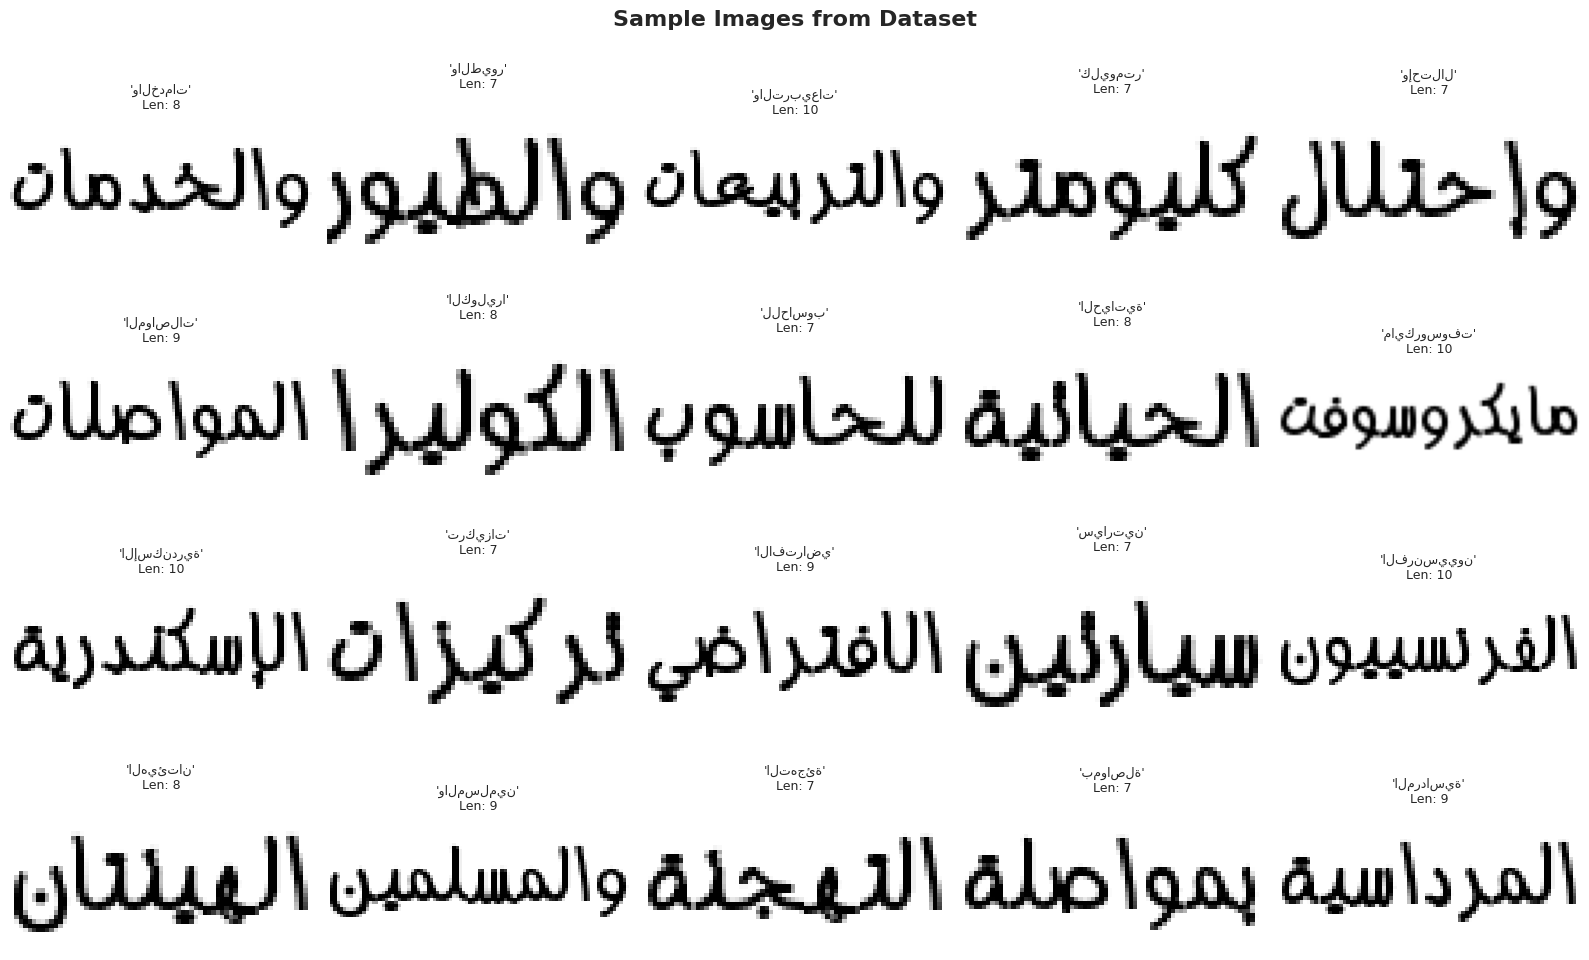

✓ Sample images visualized


In [17]:
def extract_image_from_binary(binary_file, sample):
    """Extract a single image from binary file"""
    binary_file.seek(sample.imageStartPosition)
    img_bytes = binary_file.read(sample.imageSize)
    img_array = np.frombuffer(img_bytes, dtype=np.uint8)
    img_array = img_array.reshape(sample.imageHeight, sample.imageWidth)
    return img_array

# Extract and display sample images
print("\nExtracting sample images...")

fig, axes = plt.subplots(4, 5, figsize=(16, 10))
axes = axes.flatten()

with open(BINARY_FILE, 'rb') as f:
    # Select diverse samples (different text lengths)
    sample_indices = np.linspace(0, len(samples)-1, 20, dtype=int)

    for i, idx in enumerate(sample_indices):
        img = extract_image_from_binary(f, samples[idx])
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"'{samples[idx].gtText}'\nLen: {len(samples[idx].gtText)}", fontsize=9)
        axes[i].axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'sample_images.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sample images visualized")